# Final Thesis Results Dashboard

**Research question:** Does representation stabilization imply representation sufficiency?

---

Run all cells top-to-bottom (`Kernel > Restart & Run All`).
The final cell renders the full scrollable dashboard inline in the notebook.

To export HTML: change the last line of the final cell to `build_dashboard(save_html=True)`.
Output goes to `notebooks/.generated/dashboard.html` (git-ignored, never committed).

| Cell | Purpose |
|------|---------|
| 1 | Imports + paths |
| 2 | File discovery |
| 3 | Load & inspect CSVs |
| 4 | Cross-LR matplotlib comparison figures (with mean-final-network reference line) |
| 5 | Saturation analysis tables |
| 6 | Thesis hypothesis summary table |
| 7 | `build_dashboard()` — full inline HTML dashboard |

### Dashboard sections (cell 7)

| Section | Contents |
|---------|---------|
| Learning-rate comparison | Final-epoch summary table + embedded cross-LR plots (Accuracy, CKA, NC, eNTK) |
| Per-LR sections | File list, final metrics, pre-generated plots, CSV previews |
| Saturation analysis | First-epoch thresholds with Probe95 note |
| Thesis hypothesis summary | Stabilization vs sufficiency gap table |
| Probe performance gaps | Two color-coded heatmaps: gap-to-final-network and gap-to-final-probe |


In [1]:
import os, json, base64, io, warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import HTML, display
warnings.filterwarnings("ignore")

matplotlib.rcParams["figure.dpi"] = 110
matplotlib.rcParams["axes.grid"] = True
matplotlib.rcParams["grid.alpha"] = 0.3
matplotlib.rcParams["axes.spines.top"] = False
matplotlib.rcParams["axes.spines.right"] = False

try:
    NB_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NB_DIR = os.getcwd()   # Jupyter: cwd is typically the notebook directory
BASE = os.path.normpath(os.path.join(NB_DIR, "..", "thesis_results"))
GEN_DIR = os.path.join(NB_DIR, ".generated")
os.makedirs(GEN_DIR, exist_ok=True)

RUN_DIRS = {
    "0.05": "final_lr005_seed42",
    "0.10": "final_lr010_seed42",
    "0.20": "final_lr020_seed42",
}
CSV_NAMES = [
    "master_trajectory.csv",
    "cka_summary.csv",
    "neural_collapse.csv",
    "entk_summary.csv",
    "probe_results_wide.csv",
    "probe_results_long.csv",
]
LR_COLORS = {"0.05": "#1f77b4", "0.10": "#ff7f0e", "0.20": "#2ca02c"}
print("Setup complete.  BASE =", BASE)


Setup complete.  BASE = c:\Users\gabri\thesis\thesis_results


In [2]:
# Step 1: File discovery
runs = {}
for lr, run_dir in RUN_DIRS.items():
    run_path = os.path.join(BASE, run_dir)
    info = {
        "lr": lr, "dir": run_dir, "path": run_path,
        "exists": os.path.isdir(run_path),
        "csvs": {}, "plots": [], "jsons": [],
    }
    if info["exists"]:
        res_dir   = os.path.join(run_path, "results")
        plots_dir = os.path.join(run_path, "plots")
        if os.path.isdir(res_dir):
            for f in sorted(os.listdir(res_dir)):
                fp = os.path.join(res_dir, f)
                if f.endswith(".csv"):   info["csvs"][f] = fp
                elif f.endswith(".json"):info["jsons"].append(fp)
        if os.path.isdir(plots_dir):
            for f in sorted(os.listdir(plots_dir)):
                if f.endswith(".png"):
                    info["plots"].append(os.path.join(plots_dir, f))
    runs[lr] = info

for lr, info in runs.items():
    status = "OK" if info["exists"] else "MISSING"
    print(f"LR={lr}  [{status}]  dir={info['dir']}")
    print(f"  CSVs : {list(info['csvs'].keys())}")
    print(f"  PNGs : {[os.path.basename(p) for p in info['plots']]}")
    print(f"  JSONs: {[os.path.basename(p) for p in info['jsons']]}")
    print()


LR=0.05  [OK]  dir=final_lr005_seed42
  CSVs : ['cka_summary.csv', 'entk_summary.csv', 'master_trajectory.csv', 'neural_collapse.csv', 'probe_results_long.csv', 'probe_results_wide.csv']
  PNGs : ['accuracy_trajectories.png', 'cka_heatmap.png', 'cka_local_change.png', 'cka_to_final.png', 'gap_vs_cka.png', 'learning_rate.png', 'mean_future_cka.png', 'nc1_trajectory.png']
  JSONs: ['entk_subset_indices.json']

LR=0.10  [OK]  dir=final_lr010_seed42
  CSVs : ['cka_summary.csv', 'entk_summary.csv', 'master_trajectory.csv', 'neural_collapse.csv', 'probe_results_long.csv', 'probe_results_wide.csv']
  PNGs : ['accuracy_trajectories.png', 'cka_heatmap.png', 'cka_local_change.png', 'cka_to_final.png', 'gap_vs_cka.png', 'learning_rate.png', 'mean_future_cka.png', 'nc1_trajectory.png']
  JSONs: ['entk_subset_indices.json']

LR=0.20  [OK]  dir=final_lr020_seed42
  CSVs : ['cka_summary.csv', 'entk_summary.csv', 'master_trajectory.csv', 'neural_collapse.csv', 'probe_results_long.csv', 'probe_results_

In [3]:
# Step 2: Load and inspect all CSVs
dfs = {}
for lr, info in runs.items():
    dfs[lr] = {}
    for csv_name in CSV_NAMES:
        path = info["csvs"].get(csv_name)
        if path and os.path.exists(path):
            df = pd.read_csv(path)
            dfs[lr][csv_name] = df
            miss = {c: int(n) for c, n in df.isnull().sum().items() if n > 0}
            print(f"[LR={lr}] {csv_name}  shape={df.shape}")
            print(f"  columns : {list(df.columns)}")
            print(f"  first 3 rows:")
            print(df.head(3).to_string(index=False))
            print(f"  final row:")
            print(df.tail(1).to_string(index=False))
            if miss:
                print(f"  missing : {miss}")
            print()
        else:
            print(f"[LR={lr}] {csv_name}: MISSING")


[LR=0.05] master_trajectory.csv  shape=(45, 38)
  columns : ['epoch', 'lr', 'train_loss', 'train_acc', 'network_test_acc', 'local_cka_change', 'cka_to_final', 'mean_future_cka', 'below_tau', 'nc1', 'log10_nc1', 'nc2_etf_deviation', 'nc3_weight_mean_alignment', 'nc4_ncm_disagreement', 'logistic_acc', 'linear_svm_acc', 'rbf_svm_acc', 'rf_acc', 'lightgbm_acc', 'entk_distance_prev', 'entk_distance_final', 'mean_future_entk_similarity', 'entk_within_class_mean', 'entk_between_class_mean', 'entk_within_between_ratio', 'n_subset', 'per_class_subset_size', 'bias_included', 'logistic_gap_to_final', 'logistic_relative_to_final_network', 'linear_svm_gap_to_final', 'linear_svm_relative_to_final_network', 'rbf_svm_gap_to_final', 'rbf_svm_relative_to_final_network', 'rf_gap_to_final', 'rf_relative_to_final_network', 'lightgbm_gap_to_final', 'lightgbm_relative_to_final_network']
  first 3 rows:
 epoch       lr  train_loss  train_acc  network_test_acc  local_cka_change  cka_to_final  mean_future_cka  

Mean final network acc across LRs: 0.9525


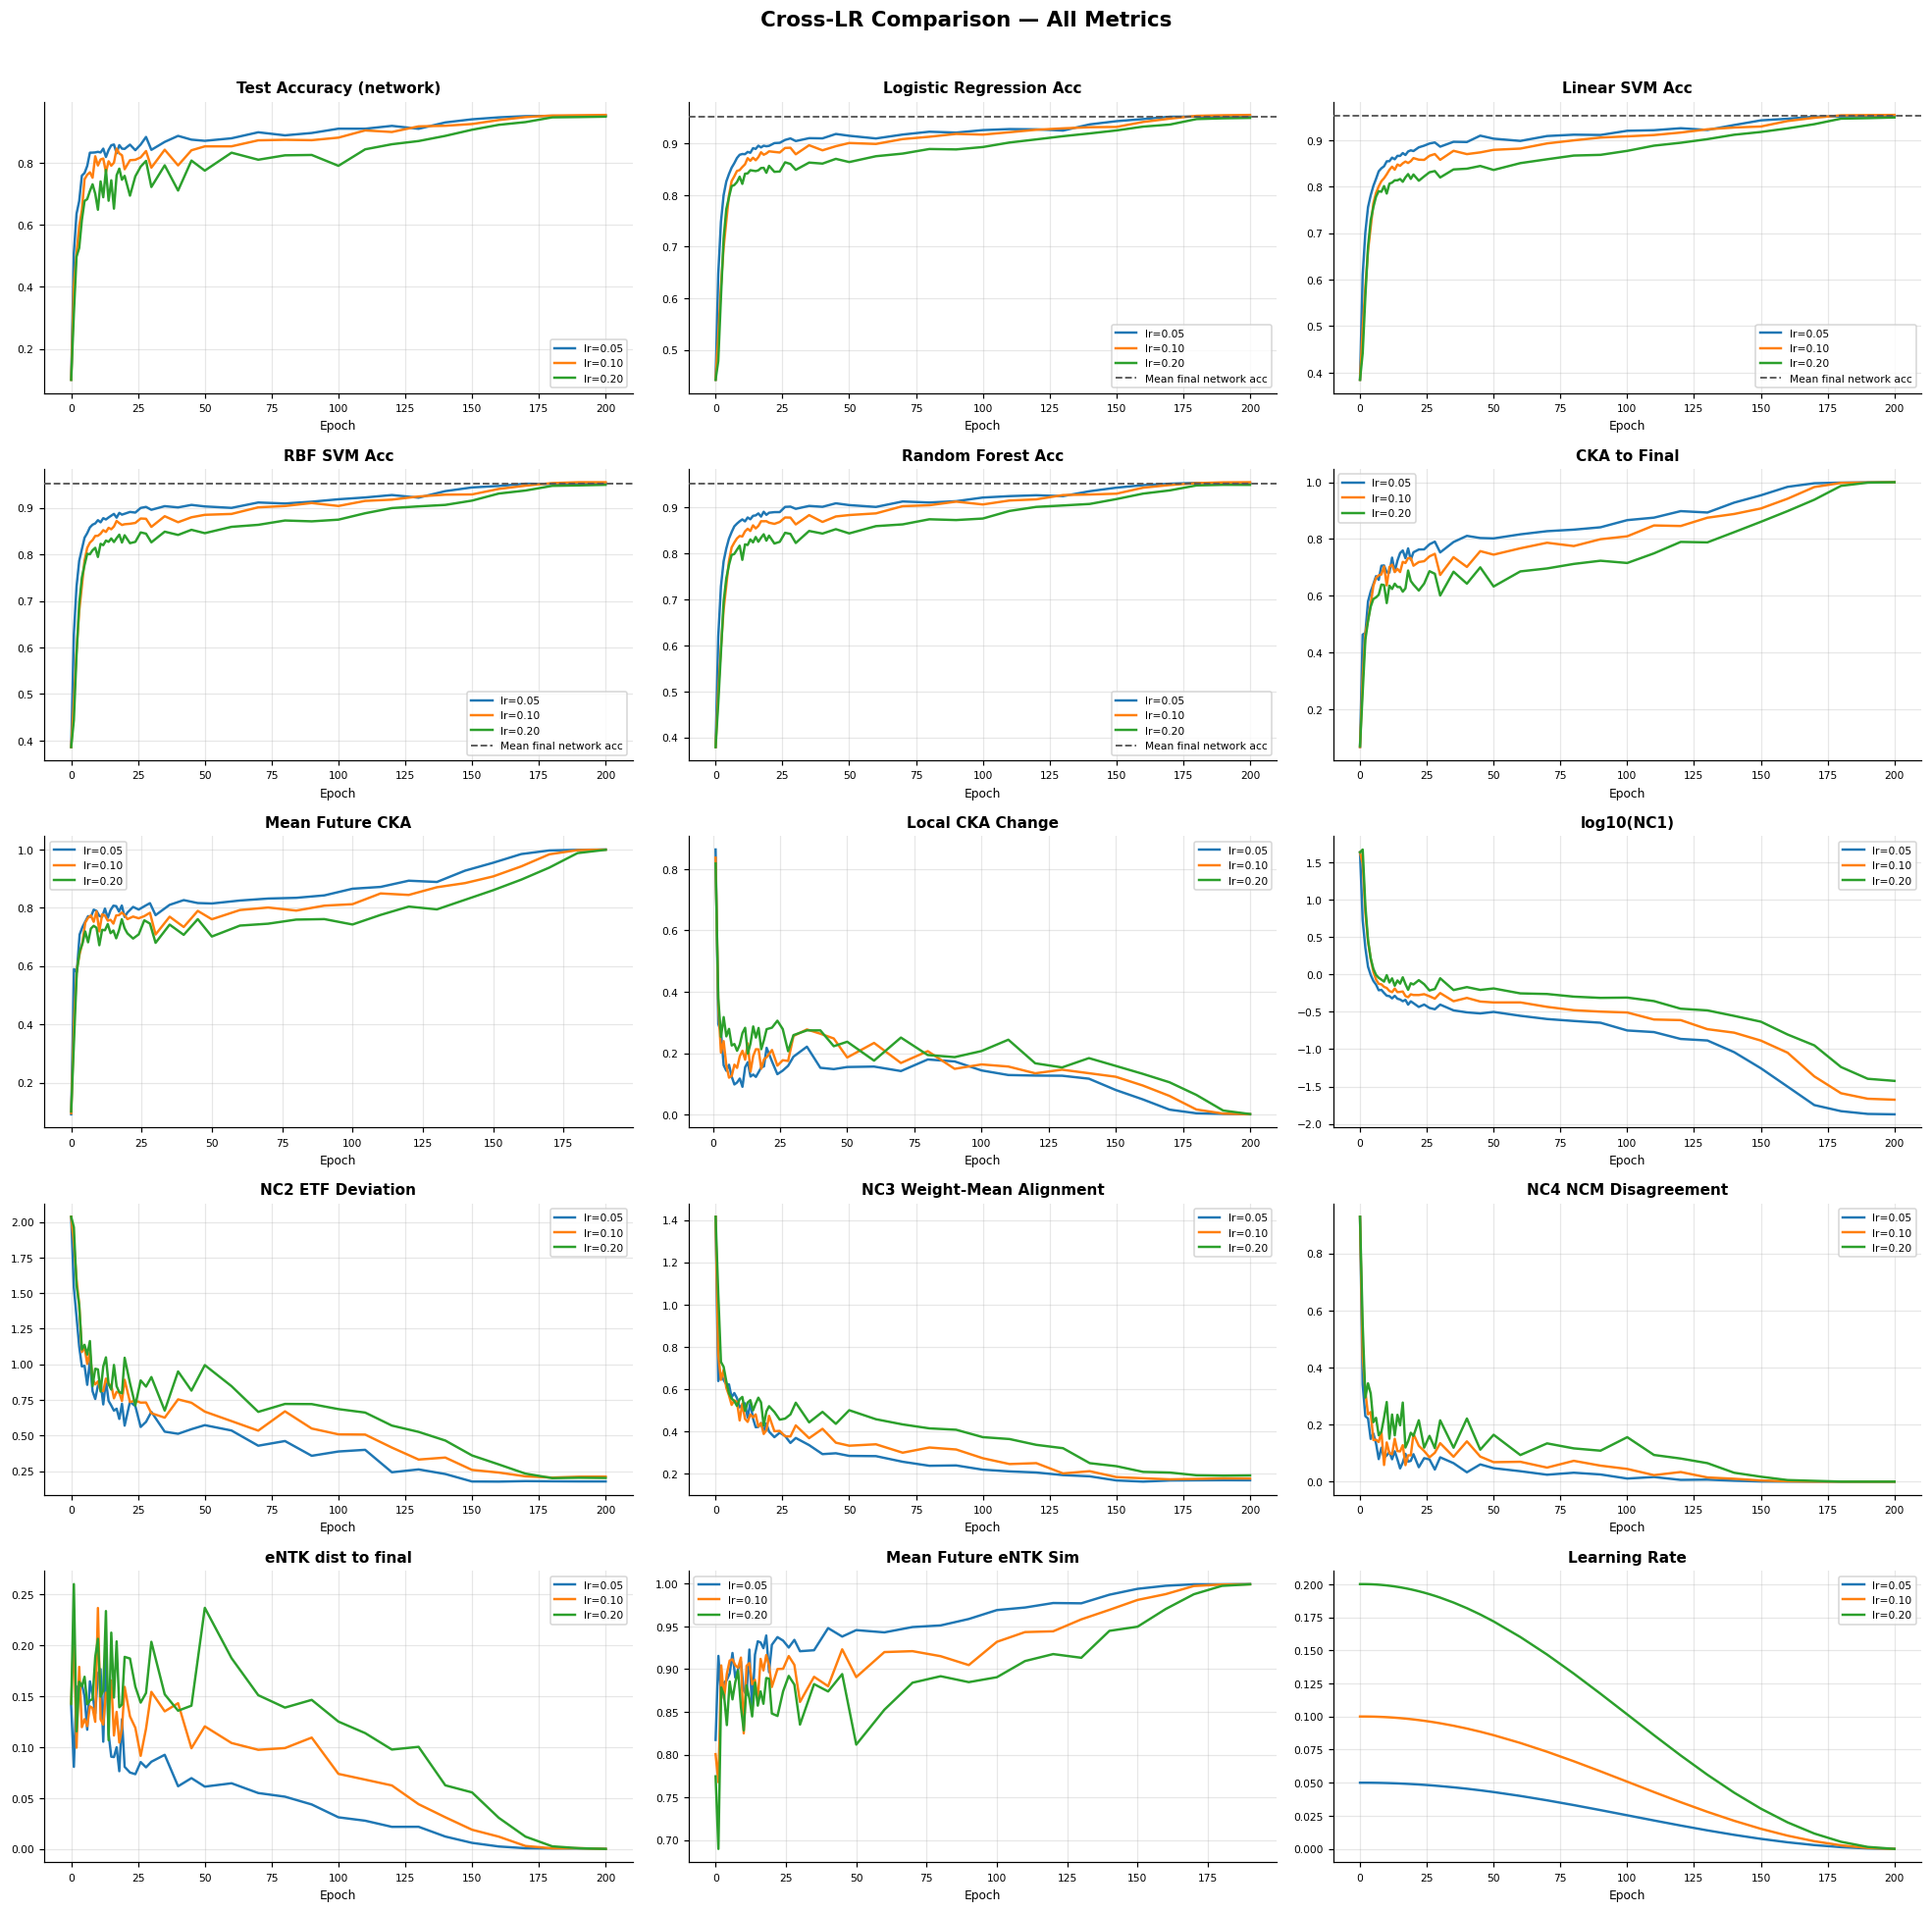

Rendered 15 panels.


In [4]:
# Step 6: Cross-LR comparison figures (matplotlib)
def _col(lr, csv, col):
    df = dfs.get(lr, {}).get(csv)
    if df is None or col not in df.columns: return None, None
    return df["epoch"], df[col]

# Probe accuracy panel titles — these receive the mean-final-network reference line
PROBE_ACC_TITLES = {
    "Logistic Regression Acc",
    "Linear SVM Acc",
    "RBF SVM Acc",
    "Random Forest Acc",
}

PANELS = [
    ("Test Accuracy (network)",   "master_trajectory.csv", "network_test_acc"),
    ("Logistic Regression Acc",   "master_trajectory.csv", "logistic_acc"),
    ("Linear SVM Acc",            "master_trajectory.csv", "linear_svm_acc"),
    ("RBF SVM Acc",               "master_trajectory.csv", "rbf_svm_acc"),
    ("Random Forest Acc",         "master_trajectory.csv", "rf_acc"),
    ("CKA to Final",              "master_trajectory.csv", "cka_to_final"),
    ("Mean Future CKA",           "master_trajectory.csv", "mean_future_cka"),
    ("Local CKA Change",          "master_trajectory.csv", "local_cka_change"),
    ("log10(NC1)",                "master_trajectory.csv", "log10_nc1"),
    ("NC2 ETF Deviation",         "master_trajectory.csv", "nc2_etf_deviation"),
    ("NC3 Weight-Mean Alignment", "master_trajectory.csv", "nc3_weight_mean_alignment"),
    ("NC4 NCM Disagreement",      "master_trajectory.csv", "nc4_ncm_disagreement"),
    ("eNTK dist to final",        "master_trajectory.csv", "entk_distance_final"),
    ("Mean Future eNTK Sim",      "master_trajectory.csv", "mean_future_entk_similarity"),
    ("Learning Rate",             "master_trajectory.csv", "lr"),
]

# Compute mean final network accuracy across available LRs (used for reference line)
_final_net_accs = []
for _lr in RUN_DIRS:
    _df = dfs.get(_lr, {}).get("master_trajectory.csv")
    if _df is not None and "network_test_acc" in _df.columns:
        _vals = _df["network_test_acc"].dropna()
        if not _vals.empty:
            _final_net_accs.append(float(_vals.iloc[-1]))
mean_final_network_acc = float(np.mean(_final_net_accs)) if _final_net_accs else None
if mean_final_network_acc is not None:
    print(f"Mean final network acc across LRs: {mean_final_network_acc:.4f}")

active = [(t, c, col) for t, c, col in PANELS
          if any(_col(lr, c, col)[0] is not None for lr in RUN_DIRS)]

if not active:
    print("No data available for cross-LR comparison plots.")
else:
    ncols  = 3
    nrows  = (len(active) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
    axes = axes.flatten() if nrows > 1 else [axes] * ncols

    for i, (title, csv, col) in enumerate(active):
        ax = axes[i]
        for lr in RUN_DIRS:
            ep, vals = _col(lr, csv, col)
            if ep is not None:
                ax.plot(ep, vals, label=f"lr={lr}", color=LR_COLORS[lr], linewidth=1.6)
        if title in PROBE_ACC_TITLES and mean_final_network_acc is not None:
            ax.axhline(
                mean_final_network_acc, color="#555555", linewidth=1.2,
                linestyle="--", label="Mean final network acc", zorder=3,
            )
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

    for i in range(len(active), len(axes)):
        axes[i].set_visible(False)

    fig.suptitle("Cross-LR Comparison — All Metrics", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"Rendered {len(active)} panels.")


In [5]:
# Step 5: Saturation analysis
def _first_epoch(df, col, thr, direction):
    if col not in df.columns: return None
    for ep, v in zip(df["epoch"], df[col]):
        if pd.isna(v): continue
        if direction == "above" and v >= thr: return int(ep)
        if direction == "below" and v <= thr: return int(ep)
    return None

PROBE_COLS   = ["logistic_acc", "linear_svm_acc", "rbf_svm_acc", "rf_acc"]
PROBE_LABELS = ["Logistic", "LinearSVM", "RBFSVM", "RandForest"]

rows = []
for lr in RUN_DIRS:
    df = dfs.get(lr, {}).get("master_trajectory.csv")
    if df is None: continue
    row = {"LR": lr}
    for pcol, plabel in zip(PROBE_COLS, PROBE_LABELS):
        if pcol not in df.columns: continue
        series = df[pcol].dropna()
        if series.empty: continue
        final_val = float(series.iloc[-1])
        for frac in [0.95, 0.97, 0.99]:
            row[f"{plabel}_{int(frac*100)}pct"] = _first_epoch(df, pcol, final_val * frac, "above")
    for col, thr, label, direction in [
        ("cka_to_final",             0.95, "cka_final_95", "above"),
        ("cka_to_final",             0.99, "cka_final_99", "above"),
        ("mean_future_cka",          0.95, "mfcka_95",     "above"),
        ("mean_future_cka",          0.99, "mfcka_99",     "above"),
        ("local_cka_change",         0.02, "local_cka_02", "below"),
        ("entk_distance_final",      0.05, "entk_dist_05", "below"),
        ("entk_distance_final",      0.01, "entk_dist_01", "below"),
        ("mean_future_entk_similarity", 0.95, "mfentk_95", "above"),
        ("mean_future_entk_similarity", 0.99, "mfentk_99", "above"),
    ]:
        row[label] = _first_epoch(df, col, thr, direction)
    rows.append(row)

if not rows:
    sat_df = pd.DataFrame(columns=["LR"])
    print("No data loaded; saturation table is empty.")
else:
    sat_df = pd.DataFrame(rows).set_index("LR")
    print("=== Saturation Epochs (first epoch reaching threshold) ===")
    print(sat_df.to_string())
    display(sat_df)


=== Saturation Epochs (first epoch reaching threshold) ===
      Logistic_95pct  Logistic_97pct  Logistic_99pct  LinearSVM_95pct  LinearSVM_97pct  LinearSVM_99pct  RBFSVM_95pct  RBFSVM_97pct  RBFSVM_99pct  RandForest_95pct  RandForest_97pct  RandForest_99pct  cka_final_95  cka_final_99  mfcka_95  mfcka_99  local_cka_02  entk_dist_05  entk_dist_01  mfentk_95  mfentk_99
LR                                                                                                                                                                                                                                                                                                                     
0.05              26             100             150               45              120              150            45           120           150                45               120               160           150           170       150       170           170            90           150         80        150
0.10 

,Logistic_95pct,Logistic_97pct,Logistic_99pct,LinearSVM_95pct,LinearSVM_97pct,LinearSVM_99pct,RBFSVM_95pct,RBFSVM_97pct,RBFSVM_99pct,RandForest_95pct,...,RandForest_99pct,cka_final_95,cka_final_99,mfcka_95,mfcka_99,local_cka_02,entk_dist_05,entk_dist_01,mfentk_95,mfentk_99
LR,,,,,,,,,,,,,,,,,,,,,
0.05,26,100,150,45,120,150,45,120,150,45,...,160,150,170,150,170,170,90,150,80,150
0.10,70,130,170,100,140,170,90,140,170,90,...,170,170,180,170,180,180,130,170,130,170
0.20,120,150,180,130,160,180,130,160,180,130,...,180,180,190,180,190,190,160,180,160,180


In [6]:
# Step 7: Thesis hypothesis summary
# Central question: Does stabilization imply sufficiency?

def _first_ep(df, col, thr, direction):
    if col not in df.columns: return None
    for ep, v in zip(df["epoch"], df[col]):
        if pd.isna(v): continue
        if direction == "above" and v >= thr: return int(ep)
        if direction == "below" and v <= thr: return int(ep)
    return None

def _probe_sat(df, col, frac):
    if col not in df.columns: return None
    series = df[col].dropna()
    if series.empty: return None
    return _first_ep(df, col, float(series.iloc[-1]) * frac, "above")

thesis_rows = []
for lr in RUN_DIRS:
    df = dfs.get(lr, {}).get("master_trajectory.csv")
    if df is None: continue
    p95_log = _probe_sat(df, "logistic_acc", 0.95)
    p95_rbf = _probe_sat(df, "rbf_svm_acc",  0.95)
    p99_log = _probe_sat(df, "logistic_acc", 0.99)
    p99_rbf = _probe_sat(df, "rbf_svm_acc",  0.99)
    local_stab  = _first_ep(df, "local_cka_change",  0.02, "below")
    global_stab = _first_ep(df, "cka_to_final",      0.99, "above")
    entk_stab   = _first_ep(df, "entk_distance_final", 0.01, "below")

    def gap(stab, probe):
        if stab is None or probe is None: return "N/A"
        return f"{stab - probe:+d}"

    thesis_rows.append({
        "LR":                          lr,
        "probe95_logistic":            p95_log,
        "probe95_rbf_svm":             p95_rbf,
        "probe99_logistic":            p99_log,
        "probe99_rbf_svm":             p99_rbf,
        "local_stab (cka<=0.02)":      local_stab,
        "global_stab (cka>=0.99)":     global_stab,
        "entk_stab (dist<=0.01)":      entk_stab,
        "gap local-probe95_rbf":       gap(local_stab,  p95_rbf),
        "gap global-probe95_rbf":      gap(global_stab, p95_rbf),
    })

if not thesis_rows:
    thesis_df = pd.DataFrame(columns=["LR"])
    print("No data loaded; thesis table is empty.")
else:
    thesis_df = pd.DataFrame(thesis_rows).set_index("LR")
    print("=== Thesis Hypothesis Table ===")
    print("Positive gap => stabilization AFTER probe saturation (stab lags sufficiency)")
    print("Negative gap => stabilization BEFORE probe saturation (stab precedes sufficiency)\n")
    print(thesis_df.to_string())
    display(thesis_df)


=== Thesis Hypothesis Table ===
Positive gap => stabilization AFTER probe saturation (stab lags sufficiency)
Negative gap => stabilization BEFORE probe saturation (stab precedes sufficiency)

      probe95_logistic  probe95_rbf_svm  probe99_logistic  probe99_rbf_svm  local_stab (cka<=0.02)  global_stab (cka>=0.99)  entk_stab (dist<=0.01) gap local-probe95_rbf gap global-probe95_rbf
LR                                                                                                                                                                                              
0.05                26               45               150              150                     170                      170                     150                  +125                   +125
0.10                70               90               170              170                     180                      180                     170                   +90                    +90
0.20               120              

,probe95_logistic,probe95_rbf_svm,probe99_logistic,probe99_rbf_svm,local_stab (cka<=0.02),global_stab (cka>=0.99),entk_stab (dist<=0.01),gap local-probe95_rbf,gap global-probe95_rbf
LR,,,,,,,,,
0.05,26,45,150,150,170,170,150,+125,+125
0.10,70,90,170,170,180,180,170,+90,+90
0.20,120,130,180,180,190,190,180,+60,+60


In [ ]:
# Step 3 / Final Cell: Full inline HTML dashboard
# ─────────────────────────────────────────────────────────────────────────────
# The cell renders a scrollable dashboard directly in the notebook.
# No permanent HTML is written unless save_html=True.

def _img_b64(path):
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    return f"data:image/png;base64,{data}"

def _fig_to_b64(fig):
    # Convert a live matplotlib figure to a base64 PNG data-URL, then close it.
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=110)
    plt.close(fig)
    buf.seek(0)
    return "data:image/png;base64," + base64.b64encode(buf.read()).decode()

def _get_df(lr, csv):
    result = dfs.get(lr, {}).get(csv)
    return result if result is not None else pd.DataFrame()

def _html_table(df, caption=None, max_rows=None):
    if df is None or (hasattr(df, "__len__") and len(df) == 0):
        return "<p><em>No data</em></p>"
    if max_rows:
        df = df.head(max_rows)
    cap = f"<caption><b>{caption}</b></caption>" if caption else ""
    header = "".join(f"<th>{c}</th>" for c in df.columns)
    body = ""
    for _, row in df.iterrows():
        cells = ""
        for v in row:
            if pd.isna(v) if not isinstance(v, str) else False:
                cells += "<td style='color:#aaa'>NaN</td>"
            elif isinstance(v, (float, np.floating)):
                cells += f"<td>{v:.5g}</td>"
            else:
                cells += f"<td>{v}</td>"
        body += f"<tr>{cells}</tr>"
    return (
        "<table border=1 cellspacing=0 cellpadding=4 "
        "style='border-collapse:collapse;font-size:11px;font-family:monospace;margin:4px 0'>"
        f"{cap}<thead style='background:#f5f5f5'><tr>{header}</tr></thead>"
        f"<tbody>{body}</tbody></table>"
    )

def _final_metrics_table(df):
    WANT = [
        "epoch", "lr", "network_test_acc",
        "local_cka_change", "cka_to_final", "mean_future_cka",
        "nc1", "log10_nc1", "nc2_etf_deviation",
        "nc3_weight_mean_alignment", "nc4_ncm_disagreement",
        "entk_distance_prev", "entk_distance_final", "mean_future_entk_similarity",
        "logistic_acc", "linear_svm_acc", "rbf_svm_acc", "rf_acc",
    ]
    if df is None or df.empty: return "<p>No data</p>"
    avail = [c for c in WANT if c in df.columns]
    final = df[avail].iloc[-1]
    rows_html = "".join(
        f"<tr><td style='font-weight:bold;background:#f9f9f9'>{col}</td>"
        f"<td>{'N/A' if pd.isna(v) else (f'{v:.6g}' if isinstance(v,(float,np.floating)) else v)}</td></tr>"
        for col, v in final.items()
    )
    return (
        "<table border=1 cellspacing=0 cellpadding=4 "
        "style='border-collapse:collapse;font-size:11px;font-family:monospace'>"
        f"<thead><tr><th>Metric</th><th>Value (epoch 200)</th></tr></thead>"
        f"<tbody>{rows_html}</tbody></table>"
    )


# ─── Cross-LR comparison figures for dashboard ───────────────────────────────

def _cross_lr_figs_html():
    # Generate cross-LR metric figures grouped by category; return embeddable HTML.
    # Recompute mean final network acc so this function is self-contained.
    _accs = []
    for _lr in RUN_DIRS:
        _df2 = dfs.get(_lr, {}).get("master_trajectory.csv")
        if _df2 is not None and "network_test_acc" in _df2.columns:
            _v = _df2["network_test_acc"].dropna()
            if not _v.empty:
                _accs.append(float(_v.iloc[-1]))
    _mean_net = float(np.mean(_accs)) if _accs else None

    _PROBE_TITLES = {
        "Logistic Regression Acc",
        "Linear SVM Acc",
        "RBF SVM Acc",
        "Random Forest Acc",
    }

    GROUPS = [
        ("Accuracy", [
            ("Test Accuracy (network)",    "network_test_acc"),
            ("Logistic Regression Acc",    "logistic_acc"),
            ("Linear SVM Acc",             "linear_svm_acc"),
            ("RBF SVM Acc",                "rbf_svm_acc"),
            ("Random Forest Acc",          "rf_acc"),
        ]),
        ("CKA Metrics", [
            ("CKA to Final",               "cka_to_final"),
            ("Mean Future CKA",            "mean_future_cka"),
            ("Local CKA Change",           "local_cka_change"),
        ]),
        ("Neural Collapse", [
            ("log10(NC1)",                 "log10_nc1"),
            ("NC2 ETF Deviation",          "nc2_etf_deviation"),
            ("NC3 Weight-Mean Alignment",  "nc3_weight_mean_alignment"),
            ("NC4 NCM Disagreement",       "nc4_ncm_disagreement"),
        ]),
        ("eNTK", [
            ("eNTK dist to final",         "entk_distance_final"),
            ("Mean Future eNTK Sim",       "mean_future_entk_similarity"),
        ]),
        ("Learning Rate Schedule", [
            ("Learning Rate",              "lr"),
        ]),
    ]

    CSV = "master_trajectory.csv"
    parts = []

    for group_name, panels in GROUPS:
        active = [
            (title, col) for title, col in panels if any(col in _get_df(lr, CSV).columns for lr in RUN_DIRS)
]
        if not active:
            continue

        ncols = min(3, len(active))
        nrows = (len(active) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), squeeze=False)
        axes_flat = axes.flatten()

        for i, (title, col) in enumerate(active):
            ax = axes_flat[i]
            for lr in RUN_DIRS:
                df2 = dfs.get(lr, {}).get(CSV)
                if df2 is not None and col in df2.columns:
                    ax.plot(df2["epoch"], df2[col], label=f"lr={lr}",
                            color=LR_COLORS[lr], linewidth=1.6)
            if title in _PROBE_TITLES and _mean_net is not None:
                ax.axhline(_mean_net, color="#555555", linewidth=1.2,
                           linestyle="--", label="Mean final network acc", zorder=3)
            ax.set_title(title, fontsize=10, fontweight="bold")
            ax.set_xlabel("Epoch", fontsize=8)
            ax.legend(fontsize=7)
            ax.tick_params(labelsize=7)

        for i in range(len(active), len(axes_flat)):
            axes_flat[i].set_visible(False)

        fig.suptitle(f"Cross-LR — {group_name}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        b64 = _fig_to_b64(fig)

        parts.append(
            f"<h4 style='font-family:monospace;color:#1a1a2e;margin:14px 0 4px 0'>"
            f"{group_name}</h4>"
            f"<img src='{b64}' style='max-width:100%;border:1px solid #ddd;"
            f"border-radius:4px;display:block'>"
        )

    return "\n".join(parts) if parts else "<p><em>No data available for cross-LR plots.</em></p>"


# ─── Probe-gap heatmap tables ─────────────────────────────────────────────────

def _gap_bg(gap_pp):
    # Map a gap value (percentage points) to an HTML background colour.
    if gap_pp > 1.0:
        return "#bbdefb"    # blue  — positive (rare/noise)
    elif gap_pp >= -2.0:
        return "#a5d6a7"    # green — within 2 pp of reference
    elif gap_pp >= -5.0:
        return "#fff9c4"    # yellow
    elif gap_pp >= -10.0:
        return "#ffe082"    # amber
    elif gap_pp >= -20.0:
        return "#ffab91"    # orange
    else:
        return "#ef9a9a"    # red   — large negative gap


def _probe_gap_html():
    # Build two per-LR heatmap tables (gap-to-final-network, gap-to-final-probe).
    PROBE_DEFS = [
        ("logistic_acc",   "Logistic"),
        ("linear_svm_acc", "LinearSVM"),
        ("rbf_svm_acc",    "RBFSVM"),
        ("rf_acc",         "RandForest"),
    ]

    TBL = ("border-collapse:collapse;font-size:10px;font-family:monospace;"
           "white-space:nowrap;min-width:max-content")
    TH  = "border:1px solid #ccc;padding:3px 6px;background:#f0f0f0;text-align:center"
    THL = "border:1px solid #ccc;padding:3px 6px;background:#f0f0f0;text-align:left"
    TD  = "border:1px solid #e0e0e0;padding:2px 5px;text-align:right"

    def _heatmap(title, note, epochs, data_rows):
        ep_heads = "".join(f"<th style='{TH}'>{int(e)}</th>" for e in epochs)
        rows_html = ""
        for label, vals in data_rows:
            cells = f"<td style='{THL}'>{label}</td>"
            for v in vals:
                if v is None:
                    cells += f"<td style='{TD};background:#f5f5f5'>—</td>"
                else:
                    bg = _gap_bg(v)
                    cells += f"<td style='{TD};background:{bg}'>{v:+.1f}</td>"
            rows_html += f"<tr>{cells}</tr>"
        return (
            f"<p style='font-size:12px;font-weight:bold;margin:10px 0 2px'>{title}</p>"
            f"<p style='font-size:11px;color:#555;margin:0 0 4px'>{note}</p>"
            f"<div style='overflow-x:auto;margin-bottom:18px'>"
            f"<table style='{TBL}'>"
            f"<thead><tr><th style='{THL}'>Probe</th>{ep_heads}</tr></thead>"
            f"<tbody>{rows_html}</tbody></table></div>"
        )

    _legend = (
        "<div style='font-size:10px;font-family:monospace;margin:8px 0 12px;display:flex;"
        "flex-wrap:wrap;gap:10px'>"
        "<span style='background:#a5d6a7;padding:2px 7px;border-radius:3px'>within 2 pp (green)</span>"
        "<span style='background:#fff9c4;padding:2px 7px;border-radius:3px'>−2 to −5 pp (yellow)</span>"
        "<span style='background:#ffe082;padding:2px 7px;border-radius:3px'>−5 to −10 pp (amber)</span>"
        "<span style='background:#ffab91;padding:2px 7px;border-radius:3px'>−10 to −20 pp (orange)</span>"
        "<span style='background:#ef9a9a;padding:2px 7px;border-radius:3px'>&lt;−20 pp (red)</span>"
        "<span style='background:#bbdefb;padding:2px 7px;border-radius:3px'>&gt;+1 pp (blue)</span>"
        "</div>"
    )

    parts = [_legend]

    for lr in RUN_DIRS:
        df = dfs.get(lr, {}).get("master_trajectory.csv")
        if df is None or "epoch" not in df.columns:
            continue
        epochs = list(df["epoch"])

        final_net_acc = None
        if "network_test_acc" in df.columns:
            _s = df["network_test_acc"].dropna()
            if not _s.empty:
                final_net_acc = float(_s.iloc[-1])

        parts.append(
            f"<h4 style='font-family:monospace;color:#1a1a2e;margin:18px 0 4px'>LR = {lr}</h4>"
        )

        # Heatmap 1: probe - final network accuracy
        rows1 = []
        for pcol, plabel in PROBE_DEFS:
            if pcol not in df.columns:
                continue
            vals = []
            for v in df[pcol]:
                if pd.isna(v) or final_net_acc is None:
                    vals.append(None)
                else:
                    vals.append((float(v) - final_net_acc) * 100.0)
            rows1.append((plabel, vals))
        if rows1:
            parts.append(_heatmap(
                "Heatmap 1 — probe accuracy minus final network accuracy (pp)",
                ("Values in percentage points. Negative = probe sits below final network "
                 "test accuracy; near-zero = probe has caught up."),
                epochs, rows1,
            ))

        # Heatmap 2: probe - final probe accuracy
        rows2 = []
        for pcol, plabel in PROBE_DEFS:
            if pcol not in df.columns:
                continue
            _s2 = df[pcol].dropna()
            if _s2.empty:
                continue
            final_probe = float(_s2.iloc[-1])
            vals = []
            for v in df[pcol]:
                if pd.isna(v):
                    vals.append(None)
                else:
                    vals.append((float(v) - final_probe) * 100.0)
            rows2.append((plabel, vals))
        if rows2:
            parts.append(_heatmap(
                "Heatmap 2 — probe accuracy minus final probe accuracy (pp)",
                ("Values in percentage points. Negative = probe is below its own "
                 "final-epoch ceiling; reaches 0 at the last checkpoint."),
                epochs, rows2,
            ))

    return "\n".join(parts)


# ─── build_dashboard ─────────────────────────────────────────────────────────

def build_dashboard(save_html=False):
    'Render inline HTML dashboard. Pass save_html=True to also write .generated/dashboard.html.'
    SEC  = ("background:#1a1a2e;color:#e0e0e0;padding:10px 20px;margin:24px 0 6px 0;"
            "font-family:monospace;font-size:15px;letter-spacing:1px;border-left:4px solid #4fc3f7")
    SUB  = ("background:#f0f4ff;color:#1a237e;padding:5px 14px;margin:10px 0 4px 0;"
            "font-family:monospace;font-size:12px;border-left:3px solid #3949ab;font-weight:bold")
    META = "font-family:monospace;font-size:11px;color:#555;margin:2px 0"
    NOTE = ("font-size:11px;color:#555;font-family:monospace;background:#fffde7;"
            "border-left:3px solid #f9a825;padding:6px 12px;margin:6px 0")

    p = []   # html parts

    # ── Header ───────────────────────────────────────────────────────────────
    p.append(
        "<div style='font-family:monospace;background:#0d0d1a;padding:20px 28px;"
        "border-radius:6px;margin-bottom:16px'>"
        "<h1 style='color:#4fc3f7;margin:0;font-size:20px;letter-spacing:2px'>"
        "FINAL THESIS RESULTS DASHBOARD</h1>"
        "<p style='color:#78909c;margin:6px 0 0 0;font-size:11px'>"
        "ResNet-18 &nbsp;·&nbsp; CIFAR-10 &nbsp;·&nbsp; SGD + CosineAnnealing"
        " &nbsp;·&nbsp; 200 epochs &nbsp;·&nbsp; seed=42<br>"
        "<b style='color:#b0bec5'>Question:</b> "
        "Does representation stabilization imply representation sufficiency?</p></div>"
    )

    # ── Learning-rate comparison ──────────────────────────────────────────────
    p.append(f"<div style='{SEC}'>LEARNING-RATE COMPARISON</div>")

    ov_rows = []
    for lr in RUN_DIRS:
        df = dfs.get(lr, {}).get("master_trajectory.csv")
        if df is None: continue
        final = df.iloc[-1]
        def g(c): return round(float(final[c]), 5) if c in final.index and not pd.isna(final[c]) else "—"
        ov_rows.append({"LR": lr,
            "test_acc":        g("network_test_acc"),
            "logistic":        g("logistic_acc"),
            "rbf_svm":         g("rbf_svm_acc"),
            "cka_local":       g("local_cka_change"),
            "cka_to_final":    g("cka_to_final"),
            "log10_nc1":       g("log10_nc1"),
            "nc2_etf_dev":     g("nc2_etf_deviation"),
            "entk_dist_final": g("entk_distance_final"),
        })
    p.append(_html_table(pd.DataFrame(ov_rows), "Final-Epoch Summary Across All Learning Rates"))

    p.append(f"<div style='{SUB}'>Cross-LR Metric Plots</div>")
    p.append(
        "<p style='font-size:11px;color:#555;margin:2px 0'>"
        "Dashed grey line on probe accuracy panels = mean final network test accuracy "
        "across all three learning rates.</p>"
    )
    p.append(_cross_lr_figs_html())

    # ── Per-LR sections ───────────────────────────────────────────────────────
    for lr, info in runs.items():
        color = LR_COLORS[lr]
        p.append(
            f"<div style='{SEC};border-left-color:{color}'>"
            f"LR = {lr} &nbsp;&#183;&nbsp; {info['dir']}</div>"
        )
        p.append(f"<p style='{META}'><b>Path:</b> {info['path']}</p>")
        p.append(f"<p style='{META}'><b>Exists:</b> {info['exists']}</p>")

        if not info["exists"]:
            p.append("<p style='color:#f44336'><b>Run directory not found.</b></p>")
            continue

        p.append(f"<div style='{SUB}'>Available Files</div>")
        p.append("<ul style='font-size:11px;font-family:monospace;color:#444;margin:4px 0 8px 20px'>")
        for fn in sorted(info["csvs"]): p.append(f"<li>results/{fn}</li>")
        for jp in info["jsons"]: p.append(f"<li>results/{os.path.basename(jp)}</li>")
        for pp_ in info["plots"]: p.append(f"<li>plots/{os.path.basename(pp_)}</li>")
        p.append("</ul>")

        p.append(f"<div style='{SUB}'>Final-Epoch Metrics (epoch 200)</div>")
        df_m = dfs.get(lr, {}).get("master_trajectory.csv")
        p.append(_final_metrics_table(df_m))

        if info["plots"]:
            p.append(f"<div style='{SUB}'>Pre-generated Plots</div>")
            p.append("<div style='display:flex;flex-wrap:wrap;gap:10px;padding:6px 0'>")
            for pp_ in sorted(info["plots"]):
                try:
                    b64  = _img_b64(pp_)
                    name = os.path.basename(pp_).replace(".png","").replace("_"," ")
                    p.append(
                        f"<figure style='margin:0;text-align:center'>"
                        f"<img src='{b64}' style='height:200px;border:1px solid #ddd;border-radius:4px'>"
                        f"<figcaption style='font-size:10px;color:#777;margin-top:2px'>{name}</figcaption>"
                        f"</figure>"
                    )
                except Exception as exc:
                    p.append(f"<p style='color:red'>Could not load {os.path.basename(pp_)}: {exc}</p>")
            p.append("</div>")

        p.append(f"<div style='{SUB}'>CSV Previews</div>")
        for csv_name in CSV_NAMES:
            df_c = dfs.get(lr, {}).get(csv_name)
            if df_c is None:
                p.append(f"<p style='color:#f44336;font-size:11px'>{csv_name}: not loaded</p>")
                continue
            p.append(
                f"<details style='margin:5px 0'>"
                f"<summary style='cursor:pointer;font-size:12px;font-weight:bold;color:#1565c0'>"
                f"{csv_name} "
                f"<span style='color:#777;font-weight:normal'>({df_c.shape[0]} rows x {df_c.shape[1]} cols)</span>"
                f"</summary>"
            )
            p.append(_html_table(df_c.head(3), f"First 3 rows — {csv_name}"))
            p.append(_html_table(df_c.tail(2), "Last 2 rows"))
            p.append("</details>")

    # ── Saturation analysis ───────────────────────────────────────────────────
    p.append(f"<div style='{SEC}'>SATURATION ANALYSIS</div>")
    p.append(
        f"<p style='{NOTE}'>"
        "<b>Note on ‘95% of final probe’ (Probe95):</b> "
        "These epochs mark the first checkpoint where a probe reaches "
        "95 % of its own final-epoch accuracy, "
        "<em>not</em> 95 % absolute accuracy. "
        "For example, if a logistic probe eventually reaches 90 % accuracy, "
        "Probe95 is the epoch where it first hits 0.95 × 90 % = 85.5 %."
        "</p>"
    )
    p.append("<p style='font-size:12px;color:#555'>First epoch reaching each threshold "
             "(None = threshold never reached).</p>")
    SAT_LABEL_MAP = {
        "Logistic_95pct":    "95% of final probe (Logistic)",
        "Logistic_97pct":    "97% of final probe (Logistic)",
        "Logistic_99pct":    "99% of final probe (Logistic)",
        "LinearSVM_95pct":   "95% of final probe (LinearSVM)",
        "LinearSVM_97pct":   "97% of final probe (LinearSVM)",
        "LinearSVM_99pct":   "99% of final probe (LinearSVM)",
        "RBFSVM_95pct":      "95% of final probe (RBFSVM)",
        "RBFSVM_97pct":      "97% of final probe (RBFSVM)",
        "RBFSVM_99pct":      "99% of final probe (RBFSVM)",
        "RandForest_95pct":  "95% of final probe (RandForest)",
        "RandForest_97pct":  "97% of final probe (RandForest)",
        "RandForest_99pct":  "99% of final probe (RandForest)",
        "cka_final_95":      "CKA-to-final ≥ 0.95",
        "cka_final_99":      "CKA-to-final ≥ 0.99",
        "mfcka_95":          "Mean future CKA ≥ 0.95",
        "mfcka_99":          "Mean future CKA ≥ 0.99",
        "local_cka_02":      "Local CKA ≤ 0.02",
        "entk_dist_05":      "eNTK dist-to-final ≤ 0.05",
        "entk_dist_01":      "eNTK distance-to-final ≤ 0.01",
        "mfentk_95":         "Mean future eNTK sim ≥ 0.95",
        "mfentk_99":         "Mean future eNTK sim ≥ 0.99",
    }
    _sat_display = sat_df.reset_index().rename(columns=SAT_LABEL_MAP)
    p.append(_html_table(_sat_display, "Saturation Epochs"))

    # ── Thesis hypothesis ─────────────────────────────────────────────────────
    p.append(f"<div style='{SEC}'>THESIS HYPOTHESIS SUMMARY</div>")
    p.append(
        "<p style='font-size:12px;color:#555'>"
        "<b>Positive gap (stab − probe95):</b> stabilization AFTER probe saturation "
        "&#8594; stab is a <em>lagging</em> indicator of sufficiency.<br>"
        "<b>Negative gap:</b> stabilization BEFORE probe saturation "
        "&#8594; stab <em>precedes</em> sufficiency.<br>"
        "<b>Near-zero gap:</b> simultaneous emergence.</p>"
    )
    THESIS_LABEL_MAP = {
        "probe95_logistic":         "95% of final probe (Logistic)",
        "probe95_rbf_svm":          "95% of final probe (RBFSVM)",
        "probe99_logistic":         "99% of final probe (Logistic)",
        "probe99_rbf_svm":          "99% of final probe (RBFSVM)",
        "local_stab (cka<=0.02)":   "Local CKA ≤ 0.02",
        "global_stab (cka>=0.99)":  "CKA-to-final ≥ 0.99",
        "entk_stab (dist<=0.01)":   "eNTK distance-to-final ≤ 0.01",
        "gap local-probe95_rbf":    "gap: Local CKA − 95% probe (RBFSVM)",
        "gap global-probe95_rbf":   "gap: CKA-to-final − 95% probe (RBFSVM)",
    }
    _thesis_display = thesis_df.reset_index().rename(columns=THESIS_LABEL_MAP)
    p.append(_html_table(_thesis_display, "Thesis Summary Table"))

    # ── Probe performance gaps ────────────────────────────────────────────────
    p.append(f"<div style='{SEC}'>PROBE PERFORMANCE GAPS OVER TRAINING</div>")
    p.append(
        f"<p style='{NOTE}'>"
        "<b>Green</b> indicates that the probe is close to the relevant "
        "final-performance ceiling; <b>red</b> indicates a larger remaining gap. "
        "Values are in percentage points (pp): negative = probe below ceiling, "
        "positive = probe above (rare, noise). "
        "Tables scroll horizontally across all 45 checkpoint epochs.</p>"
    )
    p.append(_probe_gap_html())

    # ── Footer ────────────────────────────────────────────────────────────────
    p.append(
        "<div style='font-size:10px;color:#90a4ae;margin-top:28px;"
        "border-top:1px solid #eee;padding-top:8px;font-family:monospace'>"
        "Rendered inline — no permanent HTML written unless save_html=True."
        "</div>"
    )

    full_html = "\n".join(p)
    wrapper = (
        "<div style='max-height:90vh;overflow-y:auto;overflow-x:auto;"
        "padding:16px;border:1px solid #e0e0e0;border-radius:6px;"
        "background:#fff;font-family:sans-serif'>"
        + full_html + "</div>"
    )

    if save_html:
        out_path = os.path.join(GEN_DIR, "dashboard.html")
        with open(out_path, "w", encoding="utf-8") as fh:
            fh.write(f"<!DOCTYPE html><html><head><meta charset='utf-8'></head><body>{full_html}</body></html>")
        print(f"Saved: {out_path}")

    display(HTML(wrapper))


build_dashboard(save_html=False)


ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().